In [1]:
#Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [2]:
#Load_Data
info = pd.read_csv(r"D:\MCA_AIML_Project\anonymisedData\studentInfo.csv")
assess = pd.read_csv(r"D:\MCA_AIML_Project\anonymisedData\studentAssessment.csv")
reg = pd.read_csv(r"D:\MCA_AIML_Project\anonymisedData\studentRegistration.csv")
vle = pd.read_csv(r"D:\MCA_AIML_Project\anonymisedData\studentVle.csv")

In [3]:
#Sample_Data
info = info.sample(n=2000, random_state=42)

In [4]:
#Filter_Matching_Students
ids = info['id_student']

assess = assess[assess['id_student'].isin(ids)]
reg = reg[reg['id_student'].isin(ids)]
vle = vle[vle['id_student'].isin(ids)]

In [5]:
#Assessment_Features
assess_feat = assess.groupby('id_student').agg({
    'score': ['mean', 'max', 'min', 'std'],
    'id_assessment': 'count',
    'is_banked': 'mean'
})

assess_feat.columns = [
    'score_mean','score_max','score_min','score_std',
    'total_assessments','is_banked_mean'
]

assess_feat = assess_feat.reset_index()

In [6]:
#Registration_Features
reg_feat = reg.groupby('id_student').agg({
    'date_registration': ['mean', 'min'],
    'date_unregistration': 'count'
})

reg_feat.columns = [
    'reg_mean','reg_min','unreg_count'
]

reg_feat = reg_feat.reset_index()

In [7]:
#VLE_Features
vle_feat = vle.groupby('id_student').agg({
    'id_site': 'count',
    'date': ['mean', 'max', 'min']
})

vle_feat.columns = [
    'clicks_total',
    'vle_mean','vle_max','vle_min'
]

vle_feat = vle_feat.reset_index()

# ADD NEW FEATURE (VERY IMPORTANT)
vle_feat['vle_activity_range'] = vle_feat['vle_max'] - vle_feat['vle_min']

In [8]:
#Merge
df = info.merge(assess_feat, on='id_student', how='left')
df = df.merge(reg_feat, on='id_student', how='left')
df = df.merge(vle_feat, on='id_student', how='left')
df['engagement_score'] = df['clicks_total'] * df['score_mean']

In [9]:
#Clean_Data
df = df.drop(['id_student','code_module','code_presentation'], axis=1)
df = df.fillna(0)

In [10]:
#Encode_Target
le = LabelEncoder()
y = le.fit_transform(df['final_result'])

In [11]:
#Features
X = df.drop('final_result', axis=1)
X = pd.get_dummies(X)

In [12]:
#Save_Preprocessed_Data
df.to_csv("preprocessed_student_data.csv", index=False)
print("Preprocessed data saved!")

Preprocessed data saved!


In [13]:
#Train-test_Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
#Random_Forest
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=25,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=25,
                       min_samples_leaf=2, min_samples_split=4,
                       random_state=42)

In [18]:
#Prediction
y_pred = model.predict(X_test)

In [19]:
#Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("Accuracy in %:", acc*100)

Accuracy: 0.8125
Accuracy in %: 81.25


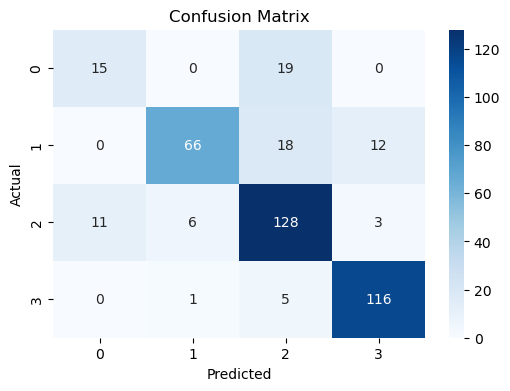

In [20]:
#Confusion_matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
#Classification_Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.44      0.50        34
           1       0.90      0.69      0.78        96
           2       0.75      0.86      0.81       148
           3       0.89      0.95      0.92       122

    accuracy                           0.81       400
   macro avg       0.78      0.74      0.75       400
weighted avg       0.81      0.81      0.81       400



In [22]:
#Save_model
import joblib

joblib.dump(model, "student_performance_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [23]:
df.to_csv("preprocessed_student_data.csv", index=False)
print("Preprocessed dataset saved!")

Preprocessed dataset saved!


In [24]:
joblib.dump(X.columns.tolist(), "model_features.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [25]:
print(X.columns.tolist())

['num_of_prev_attempts', 'studied_credits', 'score_mean', 'score_max', 'score_min', 'score_std', 'total_assessments', 'is_banked_mean', 'reg_mean', 'reg_min', 'unreg_count', 'clicks_total', 'vle_mean', 'vle_max', 'vle_min', 'vle_activity_range', 'engagement_score', 'gender_F', 'gender_M', 'region_East Anglian Region', 'region_East Midlands Region', 'region_Ireland', 'region_London Region', 'region_North Region', 'region_North Western Region', 'region_Scotland', 'region_South East Region', 'region_South Region', 'region_South West Region', 'region_Wales', 'region_West Midlands Region', 'region_Yorkshire Region', 'highest_education_A Level or Equivalent', 'highest_education_HE Qualification', 'highest_education_Lower Than A Level', 'highest_education_No Formal quals', 'highest_education_Post Graduate Qualification', 'imd_band_0', 'imd_band_0-10%', 'imd_band_10-20', 'imd_band_20-30%', 'imd_band_30-40%', 'imd_band_40-50%', 'imd_band_50-60%', 'imd_band_60-70%', 'imd_band_70-80%', 'imd_band_

In [26]:
print(df['final_result'].value_counts())

final_result
Pass           740
Withdrawn      607
Fail           481
Distinction    172
Name: count, dtype: int64


In [27]:
test = X_test.iloc[[0]]

pred = model.predict(test)

print("Prediction:", le.inverse_transform(pred))
print("Actual:", le.inverse_transform([y_test[0]]))

Prediction: ['Withdrawn']
Actual: ['Withdrawn']


In [28]:
import pandas as pd

pred = model.predict(X_test[:50])

print(pd.Series(le.inverse_transform(pred)).value_counts())

Pass           26
Withdrawn      16
Fail            5
Distinction     3
Name: count, dtype: int64


In [29]:
sample = X_test.iloc[[0]]

print(sample)

pred = model.predict(sample)

print("Prediction:", le.inverse_transform(pred))

      num_of_prev_attempts  studied_credits  score_mean  score_max  score_min  \
1155                     0              120         0.0        0.0        0.0   

      score_std  total_assessments  is_banked_mean  reg_mean  reg_min  ...  \
1155        0.0                0.0             0.0     -32.0    -32.0  ...   

      imd_band_50-60%  imd_band_60-70%  imd_band_70-80%  imd_band_80-90%  \
1155            False            False            False            False   

      imd_band_90-100%  age_band_0-35  age_band_35-55  age_band_55<=  \
1155             False           True           False          False   

      disability_N  disability_Y  
1155          True         False  

[1 rows x 53 columns]
Prediction: ['Withdrawn']


In [30]:
print(le.classes_)

['Distinction' 'Fail' 'Pass' 'Withdrawn']


In [31]:
print(X.columns.tolist())

['num_of_prev_attempts', 'studied_credits', 'score_mean', 'score_max', 'score_min', 'score_std', 'total_assessments', 'is_banked_mean', 'reg_mean', 'reg_min', 'unreg_count', 'clicks_total', 'vle_mean', 'vle_max', 'vle_min', 'vle_activity_range', 'engagement_score', 'gender_F', 'gender_M', 'region_East Anglian Region', 'region_East Midlands Region', 'region_Ireland', 'region_London Region', 'region_North Region', 'region_North Western Region', 'region_Scotland', 'region_South East Region', 'region_South Region', 'region_South West Region', 'region_Wales', 'region_West Midlands Region', 'region_Yorkshire Region', 'highest_education_A Level or Equivalent', 'highest_education_HE Qualification', 'highest_education_Lower Than A Level', 'highest_education_No Formal quals', 'highest_education_Post Graduate Qualification', 'imd_band_0', 'imd_band_0-10%', 'imd_band_10-20', 'imd_band_20-30%', 'imd_band_30-40%', 'imd_band_40-50%', 'imd_band_50-60%', 'imd_band_60-70%', 'imd_band_70-80%', 'imd_band_

In [32]:
print(df[['score_mean',
          'clicks_total',
          'reg_mean',
          'reg_min',
          'studied_credits',
          'num_of_prev_attempts']].describe())

        score_mean  clicks_total     reg_mean      reg_min  studied_credits  \
count  2000.000000    2000.00000  2000.000000  2000.000000      2000.000000   
mean     59.546479     395.80600   -70.507542   -76.175000        81.272500   
std      31.434993     452.90631    47.427784    53.304147        40.211027   
min       0.000000       0.00000  -305.000000  -305.000000        30.000000   
25%      49.383333      72.00000  -100.500000  -111.250000        60.000000   
50%      71.190909     241.00000   -59.000000   -61.500000        60.000000   
75%      82.500000     560.00000   -31.000000   -31.750000       120.000000   
max     100.000000    3765.00000   101.000000   101.000000       330.000000   

       num_of_prev_attempts  
count           2000.000000  
mean               0.187000  
std                0.525518  
min                0.000000  
25%                0.000000  
50%                0.000000  
75%                0.000000  
max                6.000000  


In [33]:
import joblib

features = joblib.load("model_features.pkl")

print(features[:10])
print("Total Features =", len(features))

['num_of_prev_attempts', 'studied_credits', 'score_mean', 'score_max', 'score_min', 'score_std', 'total_assessments', 'is_banked_mean', 'reg_mean', 'reg_min']
Total Features = 53


In [34]:
import os

print(os.getcwd())

C:\Users\loki0\Downloads\AIML- Project


In [35]:
dist_student = df[df['final_result'] == 'Distinction'].iloc[0]
print(dist_student)

gender                                      F
region                      South West Region
highest_education       A Level or Equivalent
imd_band                               50-60%
age_band                                 0-35
num_of_prev_attempts                        0
studied_credits                            60
disability                                  N
final_result                      Distinction
score_mean                              88.25
score_max                                97.0
score_min                                70.0
score_std                            6.784005
total_assessments                        12.0
is_banked_mean                            0.0
reg_mean                                -58.0
reg_min                                 -58.0
unreg_count                                 0
clicks_total                            982.0
vle_mean                            85.669043
vle_max                                 247.0
vle_min                           

In [36]:
pass_student = df[df['final_result'] == 'Pass'].iloc[0]
print(pass_student)

gender                                      M
region                                  Wales
highest_education       A Level or Equivalent
imd_band                               70-80%
age_band                                 0-35
num_of_prev_attempts                        0
studied_credits                            60
disability                                  N
final_result                             Pass
score_mean                              71.25
score_max                                94.0
score_min                                44.0
score_std                           21.061418
total_assessments                         4.0
is_banked_mean                            0.0
reg_mean                                -25.0
reg_min                                 -25.0
unreg_count                                 0
clicks_total                            604.0
vle_mean                           129.667219
vle_max                                 236.0
vle_min                           

In [37]:
withdrawn_student = df[df['final_result'] == 'Withdrawn'].iloc[0]
print(withdrawn_student)

gender                                      M
region                   North Western Region
highest_education       A Level or Equivalent
imd_band                               60-70%
age_band                                 0-35
num_of_prev_attempts                        0
studied_credits                            60
disability                                  N
final_result                        Withdrawn
score_mean                               71.0
score_max                                74.0
score_min                                68.0
score_std                            4.242641
total_assessments                         2.0
is_banked_mean                            0.0
reg_mean                                -37.0
reg_min                                 -37.0
unreg_count                                 1
clicks_total                            195.0
vle_mean                            26.594872
vle_max                                  93.0
vle_min                           